# Telecom: predicción de cancelación de clientes (churn)

## 1. Objetivo

* La empresa de telecomunicaciones quiere saber qué clientes tienen más probabilidad de cancelar su contrato, para ofrecerles promociones antes de que se vayan.
* Construimos un modelo de clasificación donde `churn = 1` significa que el cliente canceló.
* Usamos **AUC-ROC** como métrica principal y revisamos también F1 y recall, porque nos interesa encontrar a la mayor cantidad de clientes que se van.

## 2. Librerías y configuración

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_validate,
    train_test_split,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

RANDOM_STATE = 12345
DATA_DIR = Path("../data/raw")

sns.set_theme(style="whitegrid")

## 3. Carga de datos

In [2]:
contract = pd.read_csv(DATA_DIR / "contract.csv")
personal = pd.read_csv(DATA_DIR / "personal.csv")
internet = pd.read_csv(DATA_DIR / "internet.csv")
phone = pd.read_csv(DATA_DIR / "phone.csv")

for name, table in [("contract", contract), ("personal", personal), ("internet", internet), ("phone", phone)]:
    print(f"{name}: {table.shape}, customerID único: {table['customerID'].is_unique}, nulos: {table.isna().sum().sum()}")

contract: (7043, 8), customerID único: True, nulos: 0
personal: (7043, 5), customerID único: True, nulos: 0
internet: (5517, 8), customerID único: True, nulos: 0
phone: (6361, 2), customerID único: True, nulos: 0


In [3]:
contract.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [4]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


* Tenemos 4 tablas que se unen por `customerID`, sin duplicados ni nulos.
* `internet` y `phone` tienen menos filas porque no todos los clientes contratan los dos servicios.
* `TotalCharges` aparece como texto (`object`) cuando debería ser número, lo revisamos más abajo.
* En `EndDate` el valor "No" significa que el contrato sigue activo.

## 4. Limpieza y unión de las tablas

In [5]:
df = (
    contract.merge(personal, on="customerID", how="left")
    .merge(internet, on="customerID", how="left")
    .merge(phone, on="customerID", how="left")
)

df["BeginDate"] = pd.to_datetime(df["BeginDate"])
df["EndDate"] = pd.to_datetime(df["EndDate"].replace("No", pd.NA))

# Si el contrato tiene fecha de fin, el cliente canceló
df["churn"] = df["EndDate"].notna().astype(int)

df["churn"].value_counts(normalize=True)

churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [6]:
total_numeric = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.loc[total_numeric.isna(), ["customerID", "BeginDate", "MonthlyCharges", "TotalCharges"]]

,customerID,BeginDate,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,52.55,
753,3115-CZMZD,2020-02-01,20.25,
936,5709-LVOEQ,2020-02-01,80.85,
1082,4367-NUYAO,2020-02-01,25.75,
1340,1371-DWPAZ,2020-02-01,56.05,
3331,7644-OMVMY,2020-02-01,19.85,
3826,3213-VVOLG,2020-02-01,25.35,
4380,2520-SGTTA,2020-02-01,20.00,
5218,2923-ARZLG,2020-02-01,19.70,
6670,4075-WKNIU,2020-02-01,73.35,


* Hay 11 clientes con `TotalCharges` vacío y todos empezaron el 2020-02-01, que es la fecha más reciente de los datos.
* Son clientes nuevos a los que todavía no se les ha cobrado, así que les ponemos 0 en vez de eliminarlos.

In [7]:
df["TotalCharges"] = total_numeric.fillna(0)

* Después del merge, los nulos en las columnas de internet y teléfono significan que el cliente **no tiene** ese servicio. Los rellenamos con "No" y creamos dos columnas para indicar si tiene internet y si tiene teléfono.

In [8]:
internet_services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

df["has_internet"] = df["InternetService"].notna().astype(int)
df["has_phone"] = df["MultipleLines"].notna().astype(int)

df["InternetService"] = df["InternetService"].fillna("No")
df[internet_services] = df[internet_services].fillna("No")
df["MultipleLines"] = df["MultipleLines"].fillna("No")

df.drop(columns="EndDate").isna().sum().sum()

np.int64(0)

## 5. Nuevas variables

### 5.1 Antigüedad del cliente

* Para calcular cuántos meses lleva cada cliente activo necesitamos la fecha en que se sacaron los datos. La tomamos de los mismos datos: es la fecha de inicio más reciente.
* **Nota:** en la primera versión de este proyecto usé `2021-02-01` como fecha de corte. Eso le sumaba 12 meses de más a todos los clientes activos, y el modelo aprendía a separar las clases por ese error (fuga de datos). Por eso antes las métricas salían tan altas (F1 de 0.87).

In [9]:
cutoff_date = df["BeginDate"].max()
print("Fecha de corte:", cutoff_date.date())

end_date = df["EndDate"].fillna(cutoff_date)
df["tenure_months"] = (end_date - df["BeginDate"]).dt.days / 30.44

df.groupby("churn")["tenure_months"].describe().round(1)

Fecha de corte: 2020-02-01


,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
0,5174.0,37.6,24.1,0.0,15.0,38.0,61.0,72.0
1,1869.0,18.0,19.5,1.0,2.0,10.0,29.0,72.0


### 5.2 Número de servicios adicionales

In [10]:
df["n_services"] = (df[internet_services] == "Yes").sum(axis=1)
df["n_services"].value_counts().sort_index()

n_services
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

## 6. Análisis exploratorio

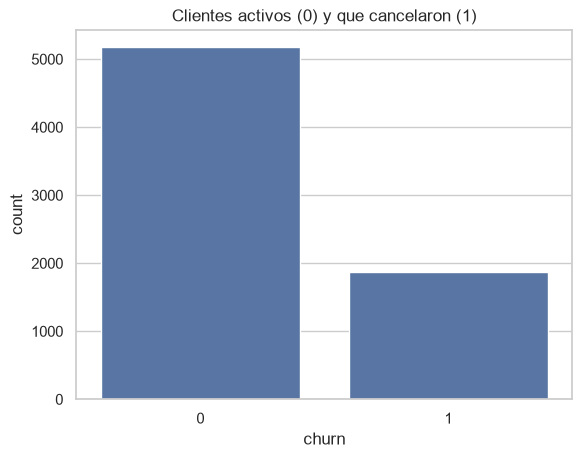

Tasa de cancelación: 26.5%


In [11]:
sns.countplot(data=df, x="churn")
plt.title("Clientes activos (0) y que cancelaron (1)")
plt.show()

print(f"Tasa de cancelación: {df['churn'].mean():.1%}")

* Solo el 26.5% de los clientes cancela, las clases están desbalanceadas.
* Por eso no usamos la exactitud como métrica principal: un modelo que siempre diga "no cancela" ya tendría 73% de exactitud.

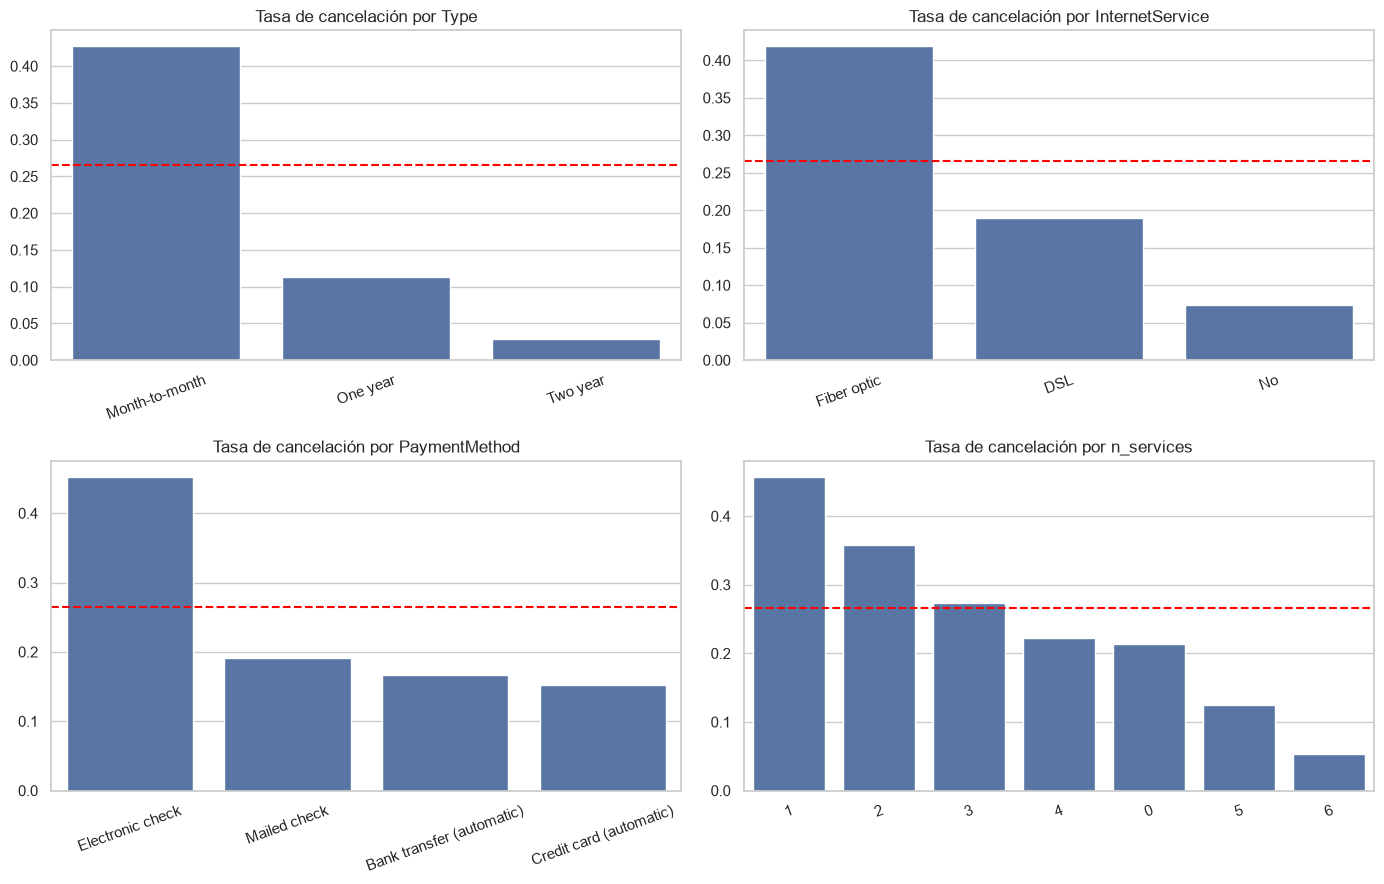

In [12]:
def plot_churn_rate(column, ax):
    rate = df.groupby(column)["churn"].mean().sort_values(ascending=False)
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax)
    ax.axhline(df["churn"].mean(), color="red", linestyle="--")
    ax.set_title(f"Tasa de cancelación por {column}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, column in zip(axes.flat, ["Type", "InternetService", "PaymentMethod", "n_services"]):
    plot_churn_rate(column, ax)
plt.tight_layout()
plt.show()

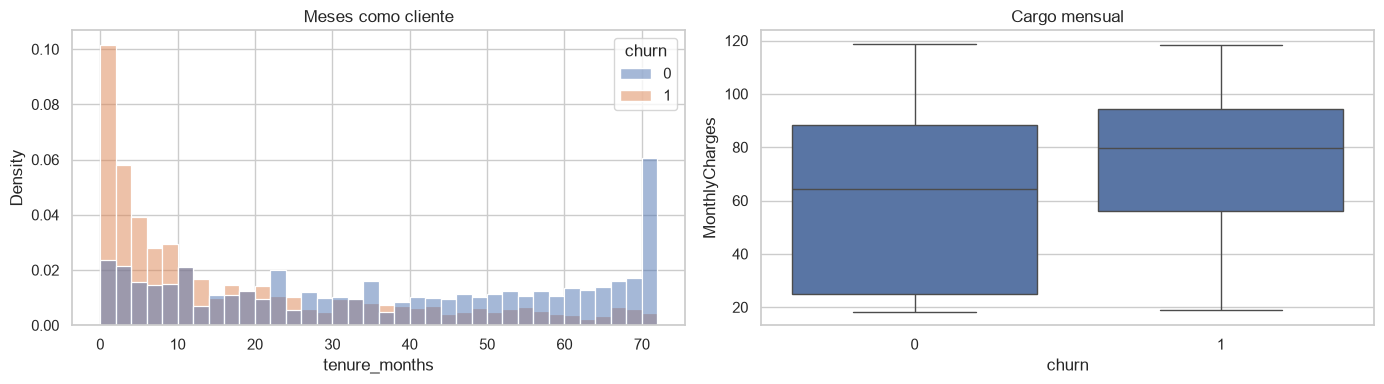

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=df, x="tenure_months", hue="churn", bins=36, stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("Meses como cliente")
sns.boxplot(data=df, x="churn", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Cargo mensual")
plt.tight_layout()
plt.show()

* Los contratos mes a mes cancelan mucho más que los de uno o dos años (la línea roja es el promedio).
* Los clientes con fibra óptica y los que pagan con cheque electrónico también cancelan más que el promedio.
* Los que cancelan llevan menos tiempo como clientes y pagan más al mes.
* A partir de 1 servicio adicional, mientras más servicios tiene un cliente, menos cancela. Los clientes con 0 servicios cancelan poco porque muchos no tienen internet.

## 7. Preparación de los datos

* Separamos entrenamiento (80%) y prueba (20%) **antes** de escalar o codificar, con `stratify` para mantener la misma proporción de churn en los dos grupos.
* El escalado y el one-hot encoding van dentro de un `Pipeline`, así solo aprenden de los datos de entrenamiento.
* Eliminamos `customerID` y las fechas, porque ya usamos su información en `tenure_months`.

In [14]:
numeric_cols = ["tenure_months", "MonthlyCharges", "TotalCharges", "n_services", "SeniorCitizen", "has_internet", "has_phone"]
categorical_cols = [
    "Type", "PaperlessBilling", "PaymentMethod", "gender", "Partner", "Dependents",
    "InternetService", "MultipleLines", *internet_services,
]

X = df[numeric_cols + categorical_cols]
y = df["churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Entrenamiento:", X_train.shape, "Prueba:", X_test.shape)

Entrenamiento: (5634, 21) Prueba: (1409, 21)


In [15]:
def make_pipeline(model, smote=False):
    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ])
    steps = [("prep", preprocessor)]
    if smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))
    steps.append(("model", model))
    return Pipeline(steps)

## 8. Modelos

### 8.1 Comparación con validación cruzada

* Probamos regresión logística, Random Forest y XGBoost, con y sin SMOTE.
* También agregamos un `DummyClassifier`, que predice al azar. Nos sirve de referencia: si un modelo no le gana, no sirve.
* Usamos validación cruzada de 5 partes solo con los datos de entrenamiento. Los datos de prueba los dejamos para el final.

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Dummy": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
}

results = []
for name, model in models.items():
    for smote in [False, True]:
        scores = cross_validate(make_pipeline(model, smote), X_train, y_train, cv=cv, scoring=["roc_auc", "f1", "recall"])
        results.append({
            "modelo": name,
            "smote": smote,
            "auc_roc": scores["test_roc_auc"].mean(),
            "f1": scores["test_f1"].mean(),
            "recall": scores["test_recall"].mean(),
        })

results = pd.DataFrame(results).sort_values("auc_roc", ascending=False)
results.round(3)

,modelo,smote,auc_roc,f1,recall
6,XGBoost,False,0.899,0.696,0.629
7,XGBoost,True,0.898,0.703,0.662
2,LogisticRegression,False,0.847,0.601,0.549
3,LogisticRegression,True,0.846,0.632,0.790
4,RandomForest,False,0.840,0.585,0.511
5,RandomForest,True,0.834,0.603,0.585
1,Dummy,True,0.509,0.353,0.498
0,Dummy,False,0.503,0.273,0.276


* Todos los modelos le ganan al Dummy (AUC-ROC de 0.5), así que sí están aprendiendo algo.
* XGBoost es el mejor, con un AUC-ROC de 0.90, seguido de la regresión logística (0.85).
* SMOTE casi no cambia el AUC-ROC. Lo que hace es subir el recall a cambio de bajar la precisión, y eso mismo lo podemos lograr moviendo el umbral de decisión (sección 8.3). Por eso seguimos sin SMOTE.

### 8.2 Ajuste de hiperparámetros

* Probamos algunas combinaciones de XGBoost con `GridSearchCV` y las comparamos con el XGBoost por defecto.

In [17]:
param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [3, 6],
    "model__learning_rate": [0.05, 0.1, 0.3],
}

grid = GridSearchCV(
    make_pipeline(XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)),
    param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
grid.fit(X_train, y_train)

default_auc = results[(results["modelo"] == "XGBoost") & (~results["smote"])]["auc_roc"].iloc[0]

print("Mejores parámetros:", grid.best_params_)
print(f"AUC-ROC con GridSearch: {grid.best_score_:.4f}")
print(f"AUC-ROC XGBoost por defecto: {default_auc:.4f}")

Mejores parámetros: {'model__learning_rate': 0.3, 'model__max_depth': 3, 'model__n_estimators': 300}
AUC-ROC con GridSearch: 0.9091
AUC-ROC XGBoost por defecto: 0.8993


* Con GridSearch el AUC-ROC sube de 0.899 a 0.909, así que nos quedamos con el modelo ajustado (`max_depth=3`, `n_estimators=300`, `learning_rate=0.3`).

In [18]:
final_model = grid.best_estimator_

### 8.3 Umbral de decisión

* Por defecto el modelo dice "cancela" cuando la probabilidad es mayor o igual a 0.5. Como hay pocos casos de churn, probamos otros umbrales para ver cuál da mejor F1.
* Para no usar los datos de prueba, sacamos las probabilidades con `cross_val_predict` sobre el conjunto de entrenamiento.

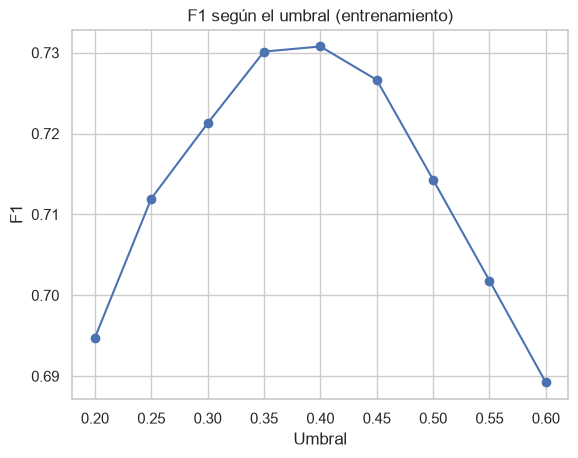

Mejor umbral: 0.4


In [19]:
train_proba = cross_val_predict(final_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

thresholds = np.arange(0.2, 0.65, 0.05).round(2)
f1_by_threshold = pd.Series([f1_score(y_train, train_proba >= t) for t in thresholds], index=thresholds)

f1_by_threshold.plot(marker="o", title="F1 según el umbral (entrenamiento)")
plt.xlabel("Umbral")
plt.ylabel("F1")
plt.show()

best_threshold = f1_by_threshold.idxmax()
print("Mejor umbral:", best_threshold)

## 9. Evaluación final con los datos de prueba

In [20]:
def evaluate(y_true, proba, threshold):
    y_pred = (proba >= threshold).astype(int)
    return {
        "AUC-ROC": roc_auc_score(y_true, proba),
        "F1": f1_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Precisión": precision_score(y_true, y_pred, zero_division=0),
        "Exactitud": accuracy_score(y_true, y_pred),
    }


dummy = make_pipeline(models["Dummy"]).fit(X_train, y_train)
test_proba = final_model.predict_proba(X_test)[:, 1]

pd.DataFrame({
    "Dummy": evaluate(y_test, dummy.predict_proba(X_test)[:, 1], 0.5),
    "XGBoost (umbral 0.5)": evaluate(y_test, test_proba, 0.5),
    f"XGBoost (umbral {best_threshold})": evaluate(y_test, test_proba, best_threshold),
}).T.round(3)

,AUC-ROC,F1,Recall,Precisión,Exactitud
Dummy,0.486,0.245,0.246,0.245,0.598
XGBoost (umbral 0.5),0.913,0.727,0.658,0.812,0.869
XGBoost (umbral 0.4),0.913,0.732,0.727,0.737,0.859


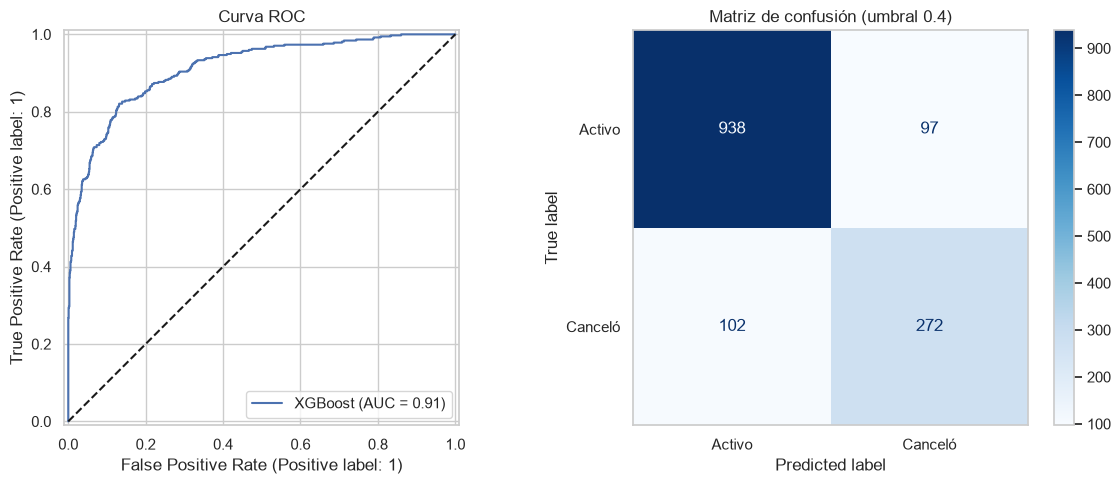

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, test_proba, name="XGBoost", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_title("Curva ROC")

ConfusionMatrixDisplay.from_predictions(
    y_test, (test_proba >= best_threshold).astype(int), display_labels=["Activo", "Canceló"], cmap="Blues", ax=axes[1]
)
axes[1].set_title(f"Matriz de confusión (umbral {best_threshold})")
axes[1].grid(False)
plt.tight_layout()
plt.show()

### 9.1 Variables más importantes

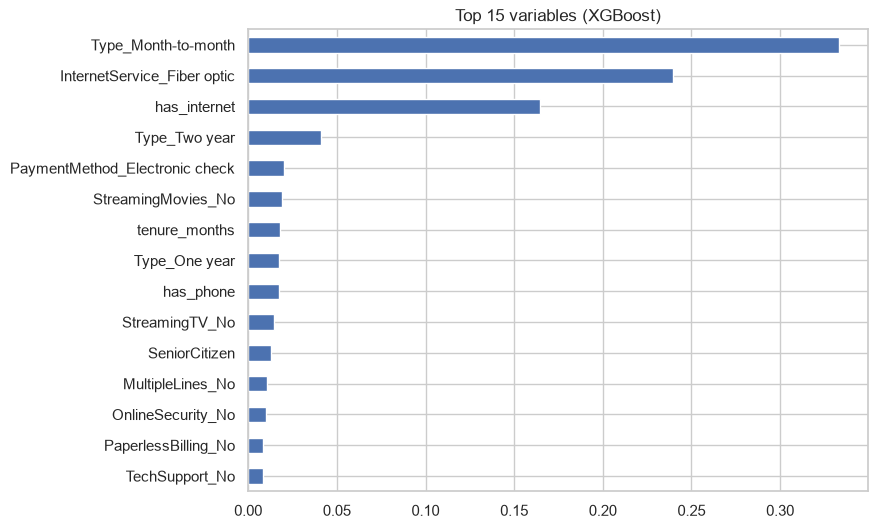

In [22]:
feature_names = final_model.named_steps["prep"].get_feature_names_out()
importance = pd.Series(final_model.named_steps["model"].feature_importances_, index=feature_names)
top = importance.sort_values(ascending=False).head(15)
top.index = top.index.str.replace("num__", "").str.replace("cat__", "")

top.sort_values().plot(kind="barh", figsize=(8, 6), title="Top 15 variables (XGBoost)")
plt.show()

## 10. Conclusiones

* El modelo final es **XGBoost ajustado con GridSearch** y un umbral de **0.4**. Con los datos de prueba obtiene:
  * AUC-ROC: **0.91**
  * F1: **0.73**
  * Recall: **0.73**, o sea que encuentra a 3 de cada 4 clientes que cancelan.
  * Precisión: **0.74**
* El AUC-ROC en prueba (0.91) es parecido al de validación cruzada (0.91), así que no vemos sobreajuste.

**Lo que aprendí en este proyecto:**

* **Fuga de datos:** con la fecha de corte equivocada las métricas salían mucho mejores (F1 de 0.87), pero eran falsas. Cuando los resultados son demasiado buenos hay que revisar de dónde salen.
* **Separar train y test antes de escalar y codificar**, y usar `Pipeline` para que no se mezclen los datos.
* **El AUC-ROC se calcula con probabilidades** (`predict_proba`), no con las predicciones 0 y 1.
* **SMOTE no siempre ayuda**: aquí mover el umbral dio el mismo efecto de forma más simple.

**Recomendaciones para la empresa:**

* Los clientes con más riesgo son los que tienen **contrato mes a mes**, **fibra óptica** y **poco tiempo** con la empresa.
* Se podrían ofrecer descuentos para pasar a contratos de 1 o 2 años, revisar el precio y la calidad de la fibra óptica, y dar más seguimiento a los clientes en sus primeros meses.

**Limitaciones:**

* Todas las cancelaciones del dataset son de octubre 2019 a enero 2020. Habría que probar el modelo con datos más nuevos antes de usarlo.